In [ ]:
#read csv:
import pandas as pd

file_path = '/content/fp-historical-wildfire-data-2006-2025.csv'
df = pd.read_csv(file_path)
display(df.head())

,YEAR,FIRE_NUMBER,FIRE_NAME,CURRENT_SIZE,SIZE_CLASS,LATITUDE,LONGITUDE,FIRE_ORIGIN,GENERAL_CAUSE,INDUSTRY_IDENTIFIER,...,DISTANCE_FROM_WATER_SOURCE,FIRST_BUCKET_DROP_DATE,FIRST_BH_DATE,FIRST_BH_SIZE,FIRST_UC_DATE,FIRST_UC_SIZE,FIRST_TO_DATE,FIRST_TO_SIZE,FIRST_EX_DATE,FIRST_EX_SIZE_PERIMETER
0,2006,PWF001,NaN,0.10,A,56.249956,-117.181960,Private Land,Resident,NaN,...,NaN,NaN,2006-04-02 22:00,0.01,2006-04-02 22:00,0.01,NaN,NaN,2006-04-03 10:20,0.10
1,2006,EWF002,NaN,0.20,B,53.606367,-115.915733,Provincial Land,Incendiary,NaN,...,NaN,NaN,2006-04-03 13:20,0.20,2006-04-03 13:20,0.20,NaN,NaN,2006-04-03 14:00,0.20
2,2006,EWF001,NaN,0.50,B,53.610933,-115.594267,Provincial Land,Incendiary,NaN,...,NaN,NaN,2006-04-03 13:23,0.50,2006-04-03 13:23,0.50,NaN,NaN,2006-04-03 15:00,0.50
3,2006,EWF003,NaN,0.01,A,53.608867,-115.609467,Provincial Land,Incendiary,NaN,...,NaN,NaN,2006-04-03 14:08,0.01,2006-04-03 14:08,0.01,NaN,NaN,2006-04-03 15:05,0.01
4,2006,PWF002,NaN,0.10,A,56.249956,-117.050249,Provincial Land,Other Industry,Waste Disposal,...,NaN,NaN,2006-04-03 19:57,0.10,2006-04-03 20:19,0.10,2006-04-03 20:20,0.1,2006-04-05 10:18,0.10


In [ ]:
print(f"The shape of the DataFrame is: {df.shape}")

The shape of the DataFrame is: (27828, 50)


## Preparing the target variable:

In [ ]:
# target variable:

import numpy as np

# Calculate the median of 'CURRENT_SIZE'
median_size = df['CURRENT_SIZE'].median()
print(f"Median 'CURRENT_SIZE': {median_size}")

# Create the 'impact_level' target variable
df['impact_level'] = np.where(df['CURRENT_SIZE'] > median_size, 'high-impact', 'low-impact')

# Value counts for the new target variable
display(df['impact_level'].value_counts())

Median 'CURRENT_SIZE': 0.02


,count
impact_level,
low-impact,13984
high-impact,13844


In [ ]:
# Convert 'impact_level' to numerical (0 for low-impact, 1 for high-impact)
df['impact_level'] = df['impact_level'].map({'low-impact': 0, 'high-impact': 1})

# Display the value counts for the new numerical target variable
display(df['impact_level'].value_counts())

# Drop the original 'CURRENT_SIZE' column as its information is now in 'impact_level'
df = df.drop('CURRENT_SIZE', axis=1)


,count
impact_level,
0,13984
1,13844


## Checking columns:

In [ ]:
# check the column details:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27828 entries, 0 to 27827
Data columns (total 50 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   YEAR                          27828 non-null  int64  
 1   FIRE_NUMBER                   27828 non-null  object 
 2   FIRE_NAME                     876 non-null    object 
 3   SIZE_CLASS                    27828 non-null  object 
 4   LATITUDE                      27828 non-null  float64
 5   LONGITUDE                     27828 non-null  float64
 6   FIRE_ORIGIN                   27816 non-null  object 
 7   GENERAL_CAUSE                 27828 non-null  object 
 8   INDUSTRY_IDENTIFIER           513 non-null    object 
 9   RESPONSIBLE_GROUP             9663 non-null   object 
 10  ACTIVITY_CLASS                16852 non-null  object 
 11  TRUE_CAUSE                    14596 non-null  object 
 12  FIRE_START_DATE               27109 non-null  object 
 13  D

In [ ]:
# the null values in the data:
missing_values = df.isnull().sum()
missing_values

,0
YEAR,0
FIRE_NUMBER,0
FIRE_NAME,26952
SIZE_CLASS,0
LATITUDE,0
LONGITUDE,0
FIRE_ORIGIN,12
GENERAL_CAUSE,0
INDUSTRY_IDENTIFIER,27315
RESPONSIBLE_GROUP,18165


In [ ]:
# deleting these columns to prevent data leakage:
columns_to_delete = [
    'ASSESSMENT_HECTARES',
    'SIZE_CLASS',
    'DISCOVERED_SIZE',
    'DISCOVERED_DATE',
    'FIRE_FIGHTING_START_SIZE',
    'FIRST_BH_SIZE',
    'FIRST_UC_SIZE',
    'FIRST_TO_SIZE',
    'FIRST_EX_SIZE_PERIMETER',
    'FIRST_BUCKET_DROP_DATE',
    'FIRST_BH_DATE',
    'FIRST_UC_DATE',
    'FIRST_TO_DATE',
    'FIRST_EX_DATE',
    'FIRE_FIGHTING_START_DATE',
    'IA_ARRIVAL_AT_FIRE_DATE'
]

# Drop columns that exist in the DataFrame
existing_columns_to_delete = [col for col in columns_to_delete if col in df.columns]

if existing_columns_to_delete:
    df.drop(columns=existing_columns_to_delete, inplace=True)
    print(f"Dropped columns: {existing_columns_to_delete}")
else:
    print("No specified columns were found in the DataFrame to drop.")

Dropped columns: ['ASSESSMENT_HECTARES', 'SIZE_CLASS', 'DISCOVERED_SIZE', 'DISCOVERED_DATE', 'FIRE_FIGHTING_START_SIZE', 'FIRST_BH_SIZE', 'FIRST_UC_SIZE', 'FIRST_TO_SIZE', 'FIRST_EX_SIZE_PERIMETER', 'FIRST_BUCKET_DROP_DATE', 'FIRST_BH_DATE', 'FIRST_UC_DATE', 'FIRST_TO_DATE', 'FIRST_EX_DATE', 'FIRE_FIGHTING_START_DATE', 'IA_ARRIVAL_AT_FIRE_DATE']


## Handling missing value:

### DROPPING COLUMNS which have more than 70 % missing values

In [ ]:
# Calculate missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

display(missing_info)

,Missing Count,Missing Percentage
INDUSTRY_IDENTIFIER,27315,98.156533
FIRE_NAME,26952,96.852091
DISTANCE_FROM_WATER_SOURCE,19709,70.824350
RESPONSIBLE_GROUP,18165,65.275981
IA_ACCESS,15525,55.789133
TRUE_CAUSE,13232,47.549231
ACTIVITY_CLASS,10976,39.442288
BUCKETING_ON_FIRE,8206,29.488285
FUEL_TYPE,7760,27.885583
WIND_DIRECTION,2935,10.546931


In [ ]:
# DROPPING COLUMNS which have more than 70 % missing values:

# Identify columns to drop (more than 70% missing values)
columns_to_drop = missing_info[missing_info['Missing Percentage'] > 70].index.tolist()

df = df.drop(columns=columns_to_drop)


In [ ]:
# Recalculate missing values for the updated DataFrame
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values
missing_info_remaining = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_info_remaining = missing_info_remaining[missing_info_remaining['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

display(missing_info_remaining)

,Missing Count,Missing Percentage
RESPONSIBLE_GROUP,18165,65.275981
IA_ACCESS,15525,55.789133
TRUE_CAUSE,13232,47.549231
ACTIVITY_CLASS,10976,39.442288
BUCKETING_ON_FIRE,8206,29.488285
FUEL_TYPE,7760,27.885583
WIND_DIRECTION,2935,10.546931
WIND_SPEED,2935,10.546931
RELATIVE_HUMIDITY,2935,10.546931
TEMPERATURE,2927,10.518183


### dropping rows for which the null values are less than 1 percent in the column

In [ ]:
# Calculate missing values and percentages for all columns in the DataFrame
missing_values_all = df.isnull().sum()
missing_percentage_all = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values (for inspection, if desired)
missing_info_all = pd.DataFrame({
    'Missing Count': missing_values_all,
    'Missing Percentage': missing_percentage_all
})

# Filter to identify columns with missing percentage less than 1% (and > 0%)
cols_to_drop_rows = missing_info_all[
    (missing_info_all['Missing Percentage'] > 0) &
    (missing_info_all['Missing Percentage'] < 1)
].index.tolist()

# Renaming for consistency with previous variable name
all_cols_to_drop_rows = cols_to_drop_rows

print(f"Columns with missing percentage less than 1% (and > 0%) to drop rows from: {all_cols_to_drop_rows}")

if all_cols_to_drop_rows:
    initial_rows = df.shape[0]
    # Drop these rows from the DataFrame
    df.dropna(subset=all_cols_to_drop_rows, inplace=True)
    rows_dropped = initial_rows - df.shape[0]
    print(f"Dropped {rows_dropped} rows due to missing values in the identified columns.")
else:
    print("No columns found with missing percentage less than 1% (and > 0%). No rows were dropped.")


Columns with missing percentage less than 1% (and > 0%) to drop rows from: ['FIRE_ORIGIN', 'DISPATCHED_RESOURCE', 'DISPATCH_DATE', 'START_FOR_FIRE_DATE', 'ASSESSMENT_RESOURCE', 'INITIAL_ACTION_BY']
Dropped 37 rows due to missing values in the identified columns.


In [ ]:
# Recalculate missing values for the updated DataFrame
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values
missing_info_remaining = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_info_remaining = missing_info_remaining[missing_info_remaining['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

display(missing_info_remaining)

,Missing Count,Missing Percentage
RESPONSIBLE_GROUP,18134,65.251340
IA_ACCESS,15496,55.759059
TRUE_CAUSE,13203,47.508186
ACTIVITY_CLASS,10949,39.397647
BUCKETING_ON_FIRE,8182,29.441186
FUEL_TYPE,7752,27.893922
WIND_DIRECTION,2926,10.528588
RELATIVE_HUMIDITY,2926,10.528588
WIND_SPEED,2926,10.528588
TEMPERATURE,2918,10.499802


### processing date columns:

In [ ]:
# extracting fire start details:
df = df.dropna(subset=['FIRE_START_DATE'])

df['FIRE_START_DATE'] = pd.to_datetime(df['FIRE_START_DATE'],  errors='coerce')

df['fire_start_month'] = df['FIRE_START_DATE'].dt.month
df['fire_start_dayofyear'] = df['FIRE_START_DATE'].dt.dayofyear
df['fire_start_hour'] = df['FIRE_START_DATE'].dt.hour


df = df.dropna(subset=['FIRE_START_DATE'])

In [ ]:
df = df.dropna(subset=['fire_start_month'])
df = df.dropna(subset=['fire_start_dayofyear'])
df = df.dropna(subset=['fire_start_hour'])

In [ ]:
# Recalculate missing values for the updated DataFrame
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values
missing_info_remaining = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort by percentage
missing_info_remaining = missing_info_remaining[missing_info_remaining['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

display(missing_info_remaining)

,Missing Count,Missing Percentage
RESPONSIBLE_GROUP,18088,66.774956
IA_ACCESS,14901,55.009598
TRUE_CAUSE,13174,48.634082
ACTIVITY_CLASS,10925,40.331512
BUCKETING_ON_FIRE,8115,29.957915
FUEL_TYPE,7107,26.236710
RELATIVE_HUMIDITY,2344,8.653278
WIND_DIRECTION,2342,8.645895
WIND_SPEED,2342,8.645895
TEMPERATURE,2337,8.627437


### cleaning the data:

In [ ]:
# Clean 'WIND_DIRECTION' column

# Replace ' S' with 'S'
df['WIND_DIRECTION'] = df['WIND_DIRECTION'].replace(' S', 'S')
# Replace ' NW' with 'NW'
df['WIND_DIRECTION'] = df['WIND_DIRECTION'].replace(' NW', 'NW')
print("Updated 'WIND_DIRECTION' value counts after cleaning:")
display(df['WIND_DIRECTION'].value_counts())



Updated 'WIND_DIRECTION' value counts after cleaning:


,count
WIND_DIRECTION,
W,5636
CLM,3430
SW,3069
NW,2953
SE,2706
E,1955
S,1817
N,1759
NE,1421


In [ ]:
import numpy as np
# Clean 'FIRE_TYPE' column

# Strip whitespace from all entries first
df['FIRE_TYPE'] = df['FIRE_TYPE'].str.strip()
# Replace empty string with np.nan
df['FIRE_TYPE'] = df['FIRE_TYPE'].replace('', np.nan)
print("Updated 'FIRE_TYPE' value counts after cleaning:")
display(df['FIRE_TYPE'].value_counts())


Updated 'FIRE_TYPE' value counts after cleaning:


,count
FIRE_TYPE,
Surface,18285
Ground,5521
Crown,1146


In [ ]:
# Convert 'y' to 'Y' in 'BUCKETING_ON_FIRE' column

df['BUCKETING_ON_FIRE'] = df['BUCKETING_ON_FIRE'].replace('y', 'Y')
print("Updated 'BUCKETING_ON_FIRE' value counts after converting 'y' to 'Y':")
display(df['BUCKETING_ON_FIRE'].value_counts())


Updated 'BUCKETING_ON_FIRE' value counts after converting 'y' to 'Y':


,count
BUCKETING_ON_FIRE,
N,10868
Y,8105


### Removing high cardinality varibales:

In [ ]:
high_cardinality_or_raw_date_cols = [
    "FIRE_NUMBER",
    "ASSESSMENT_DATETIME",
    "START_FOR_FIRE_DATE",
    "REPORTED_DATE",
    "DISPATCH_DATE",
    "DETECTION_AGENT"
    "FIRE_START_DATE"
]

existing_bad_cols = [col for col in high_cardinality_or_raw_date_cols if col in df.columns]
df.drop(columns=existing_bad_cols, inplace=True)

print("Dropped high-cardinality / raw date columns for DNN:", existing_bad_cols)
print("Shape before train-test split:", df.shape)


Dropped high-cardinality / raw date columns for DNN: ['FIRE_NUMBER', 'ASSESSMENT_DATETIME', 'START_FOR_FIRE_DATE', 'REPORTED_DATE', 'DISPATCH_DATE']
Shape before train-test split: (27088, 29)


### Handling categorical columns:

In [ ]:

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical Columns:")
print(categorical_cols)


Categorical Columns:
['FIRE_ORIGIN', 'GENERAL_CAUSE', 'RESPONSIBLE_GROUP', 'ACTIVITY_CLASS', 'TRUE_CAUSE', 'DETECTION_AGENT_TYPE', 'DETECTION_AGENT', 'DISPATCHED_RESOURCE', 'ASSESSMENT_RESOURCE', 'FIRE_TYPE', 'FIRE_POSITION_ON_SLOPE', 'WEATHER_CONDITIONS_OVER_FIRE', 'WIND_DIRECTION', 'FUEL_TYPE', 'INITIAL_ACTION_BY', 'IA_ACCESS', 'BUCKETING_ON_FIRE']


In [ ]:
# Calculate missing values for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
missing_categorical = df[categorical_cols].isnull().sum()
missing_categorical_percentage = (missing_categorical / len(df)) * 100

missing_categorical_info = pd.DataFrame({
    'Missing Count': missing_categorical,
    'Missing Percentage': missing_categorical_percentage
})

# Filter to show only columns with missing values and sort by percentage
missing_categorical_info = missing_categorical_info[missing_categorical_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing values in Categorical Columns:")
display(missing_categorical_info)

Missing values in Categorical Columns:


,Missing Count,Missing Percentage
RESPONSIBLE_GROUP,18088,66.774956
IA_ACCESS,14901,55.009598
TRUE_CAUSE,13174,48.634082
ACTIVITY_CLASS,10925,40.331512
BUCKETING_ON_FIRE,8115,29.957915
FUEL_TYPE,7107,26.236710
WIND_DIRECTION,2342,8.645895
WEATHER_CONDITIONS_OVER_FIRE,2335,8.620053
FIRE_POSITION_ON_SLOPE,2331,8.605286
FIRE_TYPE,2136,7.885411


In [ ]:
# value counts in  all the missing categorical column:
for col in missing_categorical_info.index:
    print(f"\nValue counts for column '{col}':")
    print(df[col].value_counts())
    print("\n")


Value counts for column 'RESPONSIBLE_GROUP':
RESPONSIBLE_GROUP
Campers                        4149
Resident                       2124
Others (explain in remarks)    1094
Hunters                         388
Maintenance/Service             334
Operators                       198
ATV Users                       161
Contractors                     133
Mechanized Travel               120
Contractors or Agents            52
Construction Workers             52
Employees                        36
Picnickers                       24
Animal(s)                        20
Fishermen                        18
Boat/canoe/kayak                 15
Hikers                           15
Other Employees                  12
Cover-up                         12
Dare                              9
Illness                           9
Grudge                            8
Trappers                          3
Horseback Riders                  3
Berry Pickers                     3
Employment                        2


In [ ]:
# Columns to fill with 'Unknown'
columns_to_fill_unknown = [
    'RESPONSIBLE_GROUP', 'IA_ACCESS', 'TRUE_CAUSE', 'ACTIVITY_CLASS',
    'BUCKETING_ON_FIRE', 'FUEL_TYPE', 'WIND_DIRECTION',
    'WEATHER_CONDITIONS_OVER_FIRE', 'FIRE_POSITION_ON_SLOPE', 'FIRE_TYPE'
]

# Fill missing values in these columns with 'Unknown'
for col in columns_to_fill_unknown:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')


In [ ]:
# Recalculate missing values for categorical columns to verify
missing_categorical = df[categorical_cols].isnull().sum()
missing_categorical_percentage = (missing_categorical / len(df)) * 100

missing_categorical_info_after_unknown = pd.DataFrame({
    'Missing Count': missing_categorical,
    'Missing Percentage': missing_categorical_percentage
})

# Filter to show only columns with missing values and sort by percentage
missing_categorical_info_after_unknown = missing_categorical_info_after_unknown[missing_categorical_info_after_unknown['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing values in Categorical Columns after imputing with 'Unknown':")
display(missing_categorical_info_after_unknown)


Missing values in Categorical Columns after imputing with 'Unknown':


,Missing Count,Missing Percentage


## Visualisations

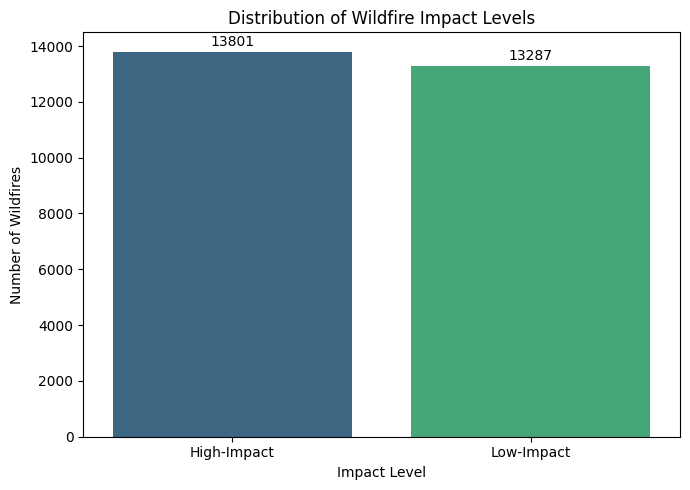

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the value counts of the 'impact_level' column
impact_counts = df['impact_level'].value_counts()

# Map numerical values back to string labels for better readability in the plot
impact_labels = {0: 'Low-Impact', 1: 'High-Impact'}
impact_counts.index = impact_counts.index.map(impact_labels)

# Bar plot
plt.figure(figsize=(7, 5))
sns.barplot(x=impact_counts.index, y=impact_counts.values, hue=impact_counts.index, palette='viridis', legend=False)

# Add title and labels
plt.title('Distribution of Wildfire Impact Levels')
plt.xlabel('Impact Level')
plt.ylabel('Number of Wildfires')
plt.xticks(rotation=0)

# Add count values on top of the bars
for index, value in enumerate(impact_counts.values):
    plt.text(index, value + 100, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

if 'impact_level' in df.columns:
    impact_counts = df['impact_level'].value_counts().reset_index()
    impact_counts.columns = ['impact_level_numeric', 'count']

    # Map numerical values back to string labels for better readability in the plot
    impact_labels = {0: 'Low-Impact', 1: 'High-Impact'}
    impact_counts['Impact Level'] = impact_counts['impact_level_numeric'].map(impact_labels)

    # Create a bar plot using Plotly Express with the 'plotly_white' template
    fig = px.bar(
        impact_counts,
        x='Impact Level',
        y='count',
        title='Distribution of Wildfire Impact Levels',
        template='plotly_white',
        color='Impact Level',
        labels={'count': 'Number of Wildfires'}
    )

    # Add count values on top of the bars
    fig.update_traces(texttemplate='%{y}', textposition='outside')
    fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')

    fig.show()
else:
    print("Error: 'impact_level' column not found in DataFrame 'df'. Please ensure previous steps were executed.")

In [ ]:
import plotly.express as px
import pandas as pd

# Prepare data for plotting
df_plot = df.copy()
impact_labels = {0: 'Low-Impact', 1: 'High-Impact'}
df_plot['Impact Level'] = df_plot['impact_level'].map(impact_labels)

# Group by 'GENERAL_CAUSE' and 'Impact Level' and count occurrences
fire_cause_impact_counts = df_plot.groupby(['GENERAL_CAUSE', 'Impact Level']).size().reset_index(name='Count')

fig = px.bar(
    fire_cause_impact_counts,
    x='GENERAL_CAUSE',
    y='Count',
    color='Impact Level',
    title='Wildfire Impact Level by General Cause',
    labels={
        'GENERAL_CAUSE': 'General Cause',
        'Count': 'Number of Wildfires',
        'Impact Level': 'Impact Level'
    },
    template='plotly_white',
    barmode='group'
)

fig.update_xaxes(tickangle=45, title_standoff=25)
fig.update_layout(height=600, showlegend=True)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Prepare data for plotting
df_plot = df.copy()
impact_labels = {0: 'Low-Impact', 1: 'High-Impact'}
df_plot['Impact Level'] = df_plot['impact_level'].map(impact_labels)

# Group by 'fire_start_hour' and 'Impact Level' and count occurrences
fire_hour_impact_counts = df_plot.groupby(['fire_start_hour', 'Impact Level']).size().reset_index(name='Count')

# a grouped bar chart using Plotly Express
fig = px.bar(
    fire_hour_impact_counts,
    x='fire_start_hour',
    y='Count',
    color='Impact Level',
    title='Wildfire Impact Level by Fire Start Hour',
    labels={
        'fire_start_hour': 'Fire Start Hour',
        'Count': 'Number of Wildfires',
        'Impact Level': 'Impact Level'
    },
    template='plotly_white',
    barmode='group'
)

fig.update_xaxes(tickangle=0, dtick=1)
fig.update_layout(height=600, showlegend=True)

fig.show()

In [ ]:
import plotly.express as px

# Prepare data for plotting
df_plot = df.copy()
impact_labels = {0: 'Low-Impact', 1: 'High-Impact'}
df_plot['Impact Level'] = df_plot['impact_level'].map(impact_labels)

# Create a violin plot for fire_start_hour by Impact Level
fig = px.violin(
    df_plot,
    x='Impact Level',
    y='fire_start_hour',
    color='Impact Level',
    box=True, # Show quartiles and median
    points='outliers', # Show outliers
    title='Distribution of Fire Start Hour by Wildfire Impact Level',
    labels={
        'Impact Level': 'Wildfire Impact Level',
        'fire_start_hour': 'Fire Start Hour'
    },
    template='plotly_white'
)

fig.update_layout(height=600, showlegend=True)
fig.show()

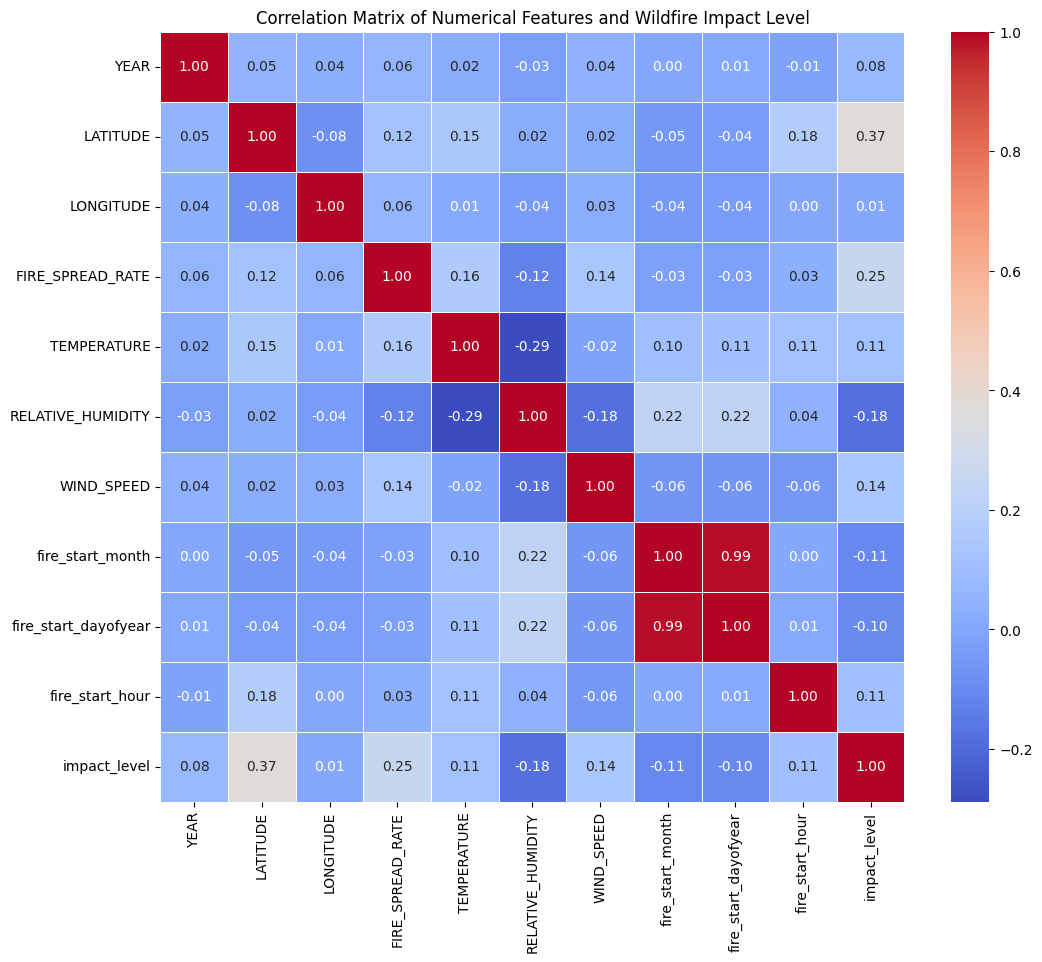

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns and the target variable for correlation analysis
numerical_and_target_cols = [
    'YEAR', 'LATITUDE', 'LONGITUDE', 'FIRE_SPREAD_RATE', 'TEMPERATURE',
    'RELATIVE_HUMIDITY', 'WIND_SPEED', 'fire_start_month', 'fire_start_dayofyear',
    'fire_start_hour', 'impact_level'
]

# Ensure only existing columns are used from the current DataFrame 'df'
existing_numerical_and_target_cols = [col for col in numerical_and_target_cols if col in df.columns]

# Calculate the correlation matrix
correlation_matrix = df[existing_numerical_and_target_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features and Wildfire Impact Level')
plt.show()

In [ ]:
import plotly.express as px

# Prepare data for plotting
df_plot_geo = df.copy()
impact_labels = {0: 'Low-Impact', 1: 'High-Impact'}
df_plot_geo['Impact Level'] = df_plot_geo['impact_level'].map(impact_labels)

# a scatter map for fire locations colored by impact level
fig = px.scatter_mapbox(
    df_plot_geo,
    lat="LATITUDE",
    lon="LONGITUDE",
    color="Impact Level",
    zoom=3,
    height=600,
    title="Wildfire Locations by Impact Level",
    hover_name="FIRE_ORIGIN", # You can add other columns here for hover info
    hover_data={'LATITUDE': False, 'LONGITUDE': False, 'YEAR': True, 'GENERAL_CAUSE': True},
    color_discrete_map={'Low-Impact': 'blue', 'High-Impact': 'red'},
    mapbox_style="carto-positron"
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

In [ ]:
import plotly.express as px

# Prepare data for plotting
df_plot = df.copy()
impact_labels = {0: 'Low-Impact', 1: 'High-Impact'}
df_plot['Impact Level'] = df_plot['impact_level'].map(impact_labels)

# a violin plot for FIRE_SPREAD_RATE by Impact Level
fig = px.violin(
    df_plot,
    x='Impact Level',
    y='FIRE_SPREAD_RATE',
    color='Impact Level',
    box=True, # Show quartiles and median
    points='outliers', # Show outliers
    title='Distribution of Fire Spread Rate by Wildfire Impact Level',
    labels={
        'Impact Level': 'Wildfire Impact Level',
        'FIRE_SPREAD_RATE': 'Fire Spread Rate'
    },
    template='plotly_white'
)

fig.update_layout(height=600, showlegend=True)
fig.show()

## After cleaning:

In [ ]:
print(f"Number of columns in df: {df.shape[1]}")

Number of columns in df: 29


In [ ]:
print(f"Number of rows in df: {df.shape[0]}")

Number of rows in df: 27088


## Splitting into train and test:

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('impact_level', axis=1)
y = df['impact_level']

# Split the data into training and testing sets
# Using a test_size of 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (21670, 28)
Shape of X_test: (5418, 28)
Shape of y_train: (21670,)
Shape of y_test: (5418,)


## Handling null numerical columns with medium from train and applying on the test to prevent data leakage:

In [ ]:
# Identify numerical columns in X_train for scaling
numerical_cols_X_train = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns in X_train:")
print(numerical_cols_X_train)


Numerical columns in X_train:
['YEAR', 'LATITUDE', 'LONGITUDE', 'FIRE_SPREAD_RATE', 'TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED', 'fire_start_month', 'fire_start_dayofyear', 'fire_start_hour']


In [ ]:
# Identify numerical columns with missing values in X_train
missing_numerical_cols_X_train = X_train[numerical_cols_X_train].isnull().sum()
missing_numerical_cols_X_train = missing_numerical_cols_X_train[missing_numerical_cols_X_train > 0].index.tolist()

print(f"Numerical columns in X_train with missing values: {missing_numerical_cols_X_train}")

# Impute missing numerical columns in X_train and X_test using medians from X_train
for col in missing_numerical_cols_X_train:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

print("\nMissing values after imputation in X_train numerical columns:")
display(X_train[numerical_cols_X_train].isnull().sum().loc[lambda x: x > 0])

print("\nMissing values after imputation in X_test numerical columns:")
display(X_test[numerical_cols_X_train].isnull().sum().loc[lambda x: x > 0])


Numerical columns in X_train with missing values: ['FIRE_SPREAD_RATE', 'TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED']

Missing values after imputation in X_train numerical columns:


,0



Missing values after imputation in X_test numerical columns:


,0


In [ ]:
print("Missing values in X_train:")
missing_in_X_train = X_train.isnull().sum()
display(missing_in_X_train[missing_in_X_train > 0])

print("\nMissing values in X_test:")
missing_in_X_test = X_test.isnull().sum()
display(missing_in_X_test[missing_in_X_test > 0])

Missing values in X_train:


,0



Missing values in X_test:


,0


## Scaling numerical values and OnehotEncoding the categorical values:

In [ ]:
# Identify categorical and numerical columns in X_train
categorical_cols_X_train = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols_X_train = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns identified:")
print(categorical_cols_X_train)
print("\nNumerical columns identified:")
print(numerical_cols_X_train)


Categorical columns identified:
['FIRE_ORIGIN', 'GENERAL_CAUSE', 'RESPONSIBLE_GROUP', 'ACTIVITY_CLASS', 'TRUE_CAUSE', 'DETECTION_AGENT_TYPE', 'DETECTION_AGENT', 'DISPATCHED_RESOURCE', 'ASSESSMENT_RESOURCE', 'FIRE_TYPE', 'FIRE_POSITION_ON_SLOPE', 'WEATHER_CONDITIONS_OVER_FIRE', 'WIND_DIRECTION', 'FUEL_TYPE', 'INITIAL_ACTION_BY', 'IA_ACCESS', 'BUCKETING_ON_FIRE']

Numerical columns identified:
['YEAR', 'LATITUDE', 'LONGITUDE', 'FIRE_SPREAD_RATE', 'TEMPERATURE', 'RELATIVE_HUMIDITY', 'WIND_SPEED', 'fire_start_month', 'fire_start_dayofyear', 'fire_start_hour']


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create preprocessor for categorical and numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_X_train),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_X_train)
    ])

# Fit and transform X_train
X_train = preprocessor.fit_transform(X_train)

# Transform X_test
X_test= preprocessor.transform(X_test)

print(f"Shape of processed X_train: {X_train.shape}")
print(f"Shape of processed X_test: {X_test.shape}")


Shape of processed X_train: (21670, 352)
Shape of processed X_test: (5418, 352)


## MODELS:

### Initial Baseline model: LR

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model on the training data
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Calculate the accuracy of the model
test_accuracy_lr = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Model Accuracy: {test_accuracy_lr:.4f}")

Logistic Regression Model Accuracy: 0.7684


### Nueral networks final model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import accuracy_score

# Define a file path to save the best model weights
checkpoint_filepath = 'best_model_weights.weights.h5'

# Create a ModelCheckpoint callback
# It monitors 'val_accuracy', saves only the best model, and is verbose (prints messages)
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# Define the simpler neural network model with L2 regularization and Dropout (same architecture as before)
model_best_checkpoint = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_best_checkpoint.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_best_checkpoint.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,217 (98.50 KB)

 Trainable params: 25,217 (98.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with the ModelCheckpoint callback
history_best_checkpoint = model_best_checkpoint.fit(
    X_train, y_train,
    epochs=20, # Increased epochs to allow more room for improvement
    batch_size=32,
    validation_split=0.2,
    callbacks=[model_checkpoint_callback]
)

Epoch 1/20
532/542 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6161 - loss: 0.7443
Epoch 1: val_accuracy improved from None to 0.76996, saving model to best_model_weights.weights.h5

Epoch 1: finished saving model to best_model_weights.weights.h5
542/542 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6705 - loss: 0.6755 - val_accuracy: 0.7700 - val_loss: 0.5386
Epoch 2/20
535/542 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7400 - loss: 0.5822
Epoch 2: val_accuracy did not improve from 0.76996
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7435 - loss: 0.5699 - val_accuracy: 0.7693 - val_loss: 0.5096
Epoch 3/20
536/542 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7566 - loss: 0.5433
Epoch 3: val_accuracy improved from 0.76996 to 0.77296, saving model to best_model_weights.weights.h5

Epoch 3: finished saving model to best_model_weights.weights.h5
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7575 - loss: 0.5414 - val_accuracy: 0.7730 - val_loss: 0.4893
Epoch 4/2

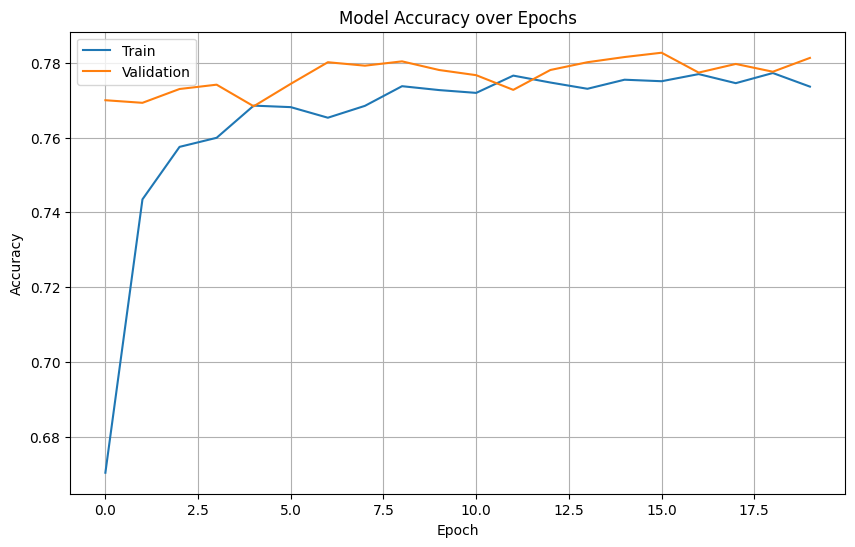

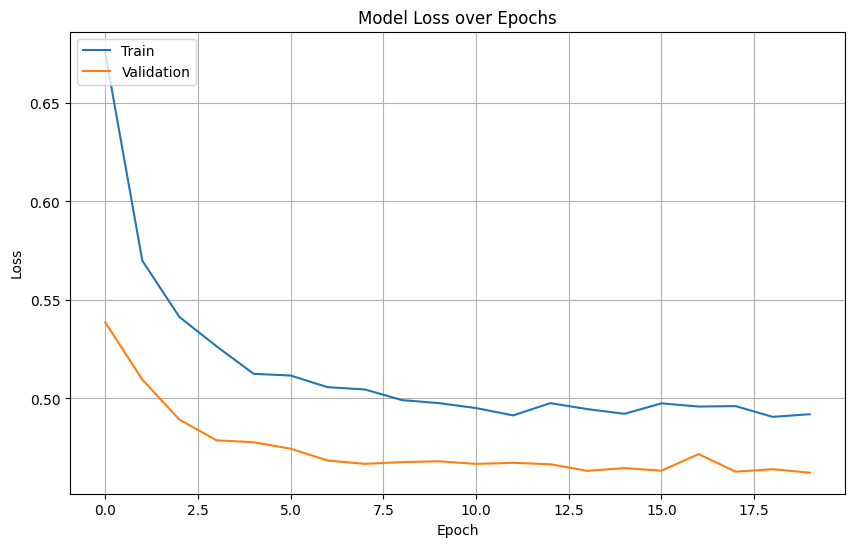

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_best_checkpoint.history['accuracy'])
plt.plot(history_best_checkpoint.history['val_accuracy'])
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_best_checkpoint.history['loss'])
plt.plot(history_best_checkpoint.history['val_loss'])
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
# Get the validation accuracy from the history object of the model trained with ModelCheckpoint
val_acc_checkpoint = history_best_checkpoint.history['val_accuracy']

# Find the epoch with the highest validation accuracy
best_epoch_checkpoint = val_acc_checkpoint.index(max(val_acc_checkpoint)) + 1 # Add 1 because epochs are 1-indexed
best_val_accuracy_checkpoint = max(val_acc_checkpoint)

print(f"The best validation accuracy for the ModelCheckpoint trained model was: {best_val_accuracy_checkpoint:.4f}")
print(f"This occurred at epoch: {best_epoch_checkpoint}")

The best validation accuracy for the ModelCheckpoint trained model was: 0.7826
This occurred at epoch: 16


In [ ]:
# Load the best weights into a new model instance (or the same one)
# Recreate the model architecture
model_final = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model (necessary before loading weights for some functionalities, though not strictly for evaluate/predict)
model_final.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Load the best weights saved during training
model_final.load_weights(checkpoint_filepath)

# Evaluate the best model on the test set
loss_final, accuracy_final = model_final.evaluate(X_test, y_test)
print(f"\nFinal Neural Network Model (Best Checkpoint) Test Accuracy: {accuracy_final:.4f}")

# Make predictions with the best model
y_pred_final_prob = model_final.predict(X_test)
y_pred_final = (y_pred_final_prob > 0.5).astype(int)

# Calculate and print accuracy again using sklearn's accuracy_score
test_accuracy_neural_model = accuracy_score(y_test, y_pred_final)
print(f"Final Neural Network Model (Best Checkpoint) Accuracy (sklearn): {test_accuracy_neural_model:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7663 - loss: 0.4829

Final Neural Network Model (Best Checkpoint) Test Accuracy: 0.7663
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Final Neural Network Model (Best Checkpoint) Accuracy (sklearn): 0.7663


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Assuming y_test and y_pred_final are available from previous cells

print("\nClassification Report for Neural Network Model:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix for Neural Network Model:")
print(confusion_matrix(y_test, y_pred_final))



Classification Report for Neural Network Model:
              precision    recall  f1-score   support

           0       0.80      0.70      0.75      2658
           1       0.74      0.83      0.78      2760

    accuracy                           0.77      5418
   macro avg       0.77      0.77      0.77      5418
weighted avg       0.77      0.77      0.77      5418


Confusion Matrix for Neural Network Model:
[[1872  786]
 [ 480 2280]]


### XGBoost Model

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import numpy as np

# Define the XGBoost model
# Using a default random_state for reproducibility
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

In [ ]:
# Define the hyperparameter space for RandomizedSearchCV
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 4, 5, 6, 7, 8], # Maximum depth of a tree
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], # Subsample ratio of the training instance
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0], # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2, 0.3, 0.4], # Minimum loss reduction required to make a further partition on a leaf node of the tree
    'lambda': [1, 1.5, 2], # L2 regularization term on weights
    'alpha': [0, 0.1, 0.5] # L1 regularization term on weights
}

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled (choose a reasonable number based on computational resources)
# cv: Number of cross-validation folds
# scoring: Metric to evaluate the model (accuracy is a common choice for classification)
# verbose: Controls the verbosity of the output
# random_state: For reproducibility
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=50, # You can increase this for a more thorough search if computational resources allow
    cv=3, # Using 3-fold cross-validation
    scoring='accuracy',
    verbose=2,
    n_jobs=-1, # Use all available CPU cores
    random_state=42
)

print("Starting Randomized Search for XGBoost...")

Starting Randomized Search for XGBoost...


In [ ]:
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("Randomized Search completed.")

# Get the best estimator and its parameters
best_xgb_model = random_search.best_estimator_
best_params = random_search.best_params_

print(f"\nBest hyperparameters found: {best_params}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Randomized Search completed.

Best hyperparameters found: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'lambda': 1.5, 'gamma': 0.4, 'colsample_bytree': 0.6, 'alpha': 0.5}
Best cross-validation accuracy: 0.7909


In [ ]:
# Make predictions on the test set using the best model
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_pred_proba_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the best model
test_accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
print(f"\nAccuracy of the best XGBoost model on the test set: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")

print("\nClassification Report for the best XGBoost model:\n")
print(classification_report(y_test, y_pred_xgb_tuned))

print("\nConfusion Matrix for the best XGBoost model:\n")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print(f"\nROC-AUC Score for the best XGBoost model: {roc_auc_score(y_test, y_pred_proba_xgb_tuned):.4f}")


Accuracy of the best XGBoost model on the test set: 0.7937

Classification Report for the best XGBoost model:

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2658
           1       0.79      0.81      0.80      2760

    accuracy                           0.79      5418
   macro avg       0.79      0.79      0.79      5418
weighted avg       0.79      0.79      0.79      5418


Confusion Matrix for the best XGBoost model:

[[2073  585]
 [ 533 2227]]

ROC-AUC Score for the best XGBoost model: 0.8869


In [ ]:
import pandas as pd

# Ensure feature_names is correctly defined from the preprocessor if not already global
# Assuming preprocessor is still available and has a get_feature_names_out() method
# If preprocessor was modified or is not in scope, you might need to re-create it or adjust this part.

feature_names = preprocessor.get_feature_names_out()

# Get importance from the best model
importance_tuned = best_xgb_model.feature_importances_

feature_importance_tuned = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_tuned
}).sort_values(by="Importance", ascending=False)

print("Top 20 Important Features from the Tuned XGBoost Model:\n")
print(feature_importance_tuned.head(20))

Top 20 Important Features from the Tuned XGBoost Model:

                                     Feature  Importance
37            cat__RESPONSIBLE_GROUP_Campers    0.137735
327                   cat__FUEL_TYPE_Unknown    0.079812
3                      num__FIRE_SPREAD_RATE    0.061103
295      cat__FIRE_POSITION_ON_SLOPE_Unknown    0.050883
27             cat__GENERAL_CAUSE_Recreation    0.026805
311              cat__WIND_DIRECTION_Unknown    0.023620
351                 cat__BUCKETING_ON_FIRE_Y    0.014806
122            cat__DETECTION_AGENT_TYPE_GRP    0.012263
287                     cat__FIRE_TYPE_Crown    0.009922
290                   cat__FIRE_TYPE_Unknown    0.009398
123            cat__DETECTION_AGENT_TYPE_LKT    0.007068
323                       cat__FUEL_TYPE_O1a    0.006578
17   cat__GENERAL_CAUSE_Agriculture Industry    0.006299
21              cat__GENERAL_CAUSE_Lightning    0.006091
328        cat__INITIAL_ACTION_BY_Air Tanker    0.005678
350           cat__BUCKETING_ON

## final test accuracies:

In [ ]:
from sklearn.metrics import accuracy_score

# Neural Network (Best Checkpoint) Test Accuracy
print(f"Neural Network Model (Best Checkpoint) Test Accuracy: {test_accuracy_neural_model:.4f}")

# XGBoost Model Test Accuracy

print(f"XGBoost Model Test Accuracy: {test_accuracy_xgb_tuned:.4f}")

# Logistic Regression (Baseline) Test Accuracy
print(f"Logistic Regression (Baseline) Test Accuracy: {test_accuracy_lr:.4f}")

Neural Network Model (Best Checkpoint) Test Accuracy: 0.7717
XGBoost Model Test Accuracy: 0.7937
Logistic Regression (Baseline) Test Accuracy: 0.7684


170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


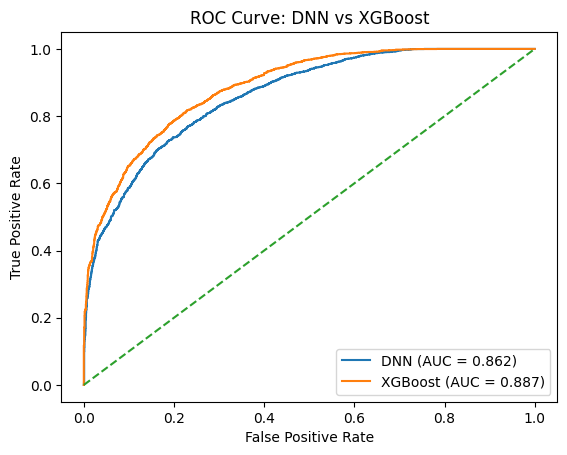

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. DNN Predictions
# Get probability predictions (not class labels)
y_pred_dnn_prob = model_final.predict(X_test).ravel()

# Compute ROC curve and AUC
fpr_dnn, tpr_dnn, _ = roc_curve(y_test, y_pred_dnn_prob)
roc_auc_dnn = auc(fpr_dnn, tpr_dnn)


# 2. XGBoost Predictions
# Use predict_proba for probabilities
y_pred_xgb_prob = best_xgb_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb_prob)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)


# 3. Plot ROC Curves
plt.figure()

plt.plot(fpr_dnn, tpr_dnn, label=f"DNN (AUC = {roc_auc_dnn:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: DNN vs XGBoost")
plt.legend(loc="lower right")

plt.show()